In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vct import clean, config, evaluate as ev, experiments as X
from vct.models import BradleyTerry, Glicko2, BTConfig
from vct.simulate import (SeriesModel, Scaled, Offset, VetoHabits, map_pool,
                          market_offsets, title_odds, pick_sheet)

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 70)

RUN_PIPELINE = False
if RUN_PIPELINE:
    from vct.scrape import scrape
    scrape()
    clean.build()
    X.run()

In [26]:
series, maps = clean.load("series"), clean.load("maps")
players, vetoes, upcoming = clean.load("players"), clean.load("vetoes"), clean.load("upcoming")
aliases = pd.read_csv(config.ALIASES)

teams = pd.unique(series[["team_a", "team_b"]].values.ravel())
print(f"{len(series):,} series, {len(maps):,} maps, {len(teams)} teams, {series.event.nunique()} events, "
      f"{series.date.min():%Y-%m-%d} to {series.date.max():%Y-%m-%d}")
print(f"round scores on {len(maps):,} maps; vetoes on {vetoes.match_id.nunique():,} series; "
      f"market odds on {series.p_market.notna().sum():,} series")
series.groupby("event", sort=False).size().rename("series").to_frame().T

1,217 series, 3,065 maps, 79 teams, 32 events, 2025-01-11 to 2026-10-04
round scores on 3,065 maps; vetoes on 1,185 series; market odds on 1,161 series


event,2025 China Kickoff,2025 EMEA Kickoff,2025 Americas Kickoff,2025 Pacific Kickoff,2025 Masters Bangkok,2025 China Stage 1,2025 Americas Stage 1,2025 Pacific Stage 1,2025 EMEA Stage 1,2025 Esports World Cup,...,2026 EMEA Stage 1,2026 Pacific Stage 1,2026 Americas Stage 1,2026 Masters London,2026 Esports World Cup,2026 China Stage 2,2026 EMEA Stage 2,2026 Pacific Stage 2,2026 Americas Stage 2,2026 Champions Shanghai
series,22,22,22,22,17,42,42,42,42,77,...,42,42,42,24,28,66,60,60,60,20


In [27]:
# data checks: duplicates, map scores vs series score, dates, best-of, unknown teams
issues = clean.validate(series, maps, aliases)
print("errors:", (issues.severity == "error").sum(), "| warnings:", (issues.severity == "warning").sum())
issues.groupby(["severity", "check"]).size().rename("count").to_frame()

errors: 0 | warnings: 0


,,count
severity,check,


In [28]:
maps.tail(5)

,match_id,game_id,map_order,date,event,event_id,region_a,region_b,team_a,team_b,map,rounds_a,rounds_b,y,picked_by,best_of,lan,international
3060,753463,283210,3,2026-10-03,2026 Champions Shanghai,2766,EMEA,Pacific,KC,NS,Haven,6,13,0,decider,3,True,True
3061,753448,283163,1,2026-10-04,2026 Champions Shanghai,2766,EMEA,Pacific,FUT,T1,Sunset,10,13,0,T1,3,True,True
3062,753448,283164,2,2026-10-04,2026 Champions Shanghai,2766,EMEA,Pacific,FUT,T1,Ascent,10,13,0,FUT,3,True,True
3063,753453,283178,1,2026-10-04,2026 Champions Shanghai,2766,Americas,Pacific,LOUD,GE,Split,13,8,1,GE,3,True,True
3064,753453,283179,2,2026-10-04,2026 Champions Shanghai,2766,Americas,Pacific,LOUD,GE,Sunset,13,9,1,LOUD,3,True,True


In [29]:
log = pd.read_csv(config.EXPERIMENTS)
cols = ["change", "log_loss", "ll_low", "ll_high", "brier", "accuracy", "n_series",
        "delta_vs_best", "delta_low", "delta_high", "keep"]
log[cols].style.format({c: "{:.4f}" for c in cols[1:6] + cols[7:10]} | {"accuracy": "{:.1%}"}, na_rep="")

,change,log_loss,ll_low,ll_high,brier,accuracy,n_series,delta_vs_best,delta_low,delta_high,keep
0,Original notebook (40 hand-entered series),0.6880,,,,41.0%,32,,,,historical
1,Baseline: coin flip,0.6931,0.6931,0.6931,0.2500,49.7%,746,,,,baseline
2,"Baseline: Phase 0 model (event decay 0.5, C=0.2)",0.6721,0.6641,0.6802,0.2397,59.8%,746,,,,yes
3,"2b: half_life=60, C=0.3",0.6486,0.6330,0.6639,0.2286,63.1%,746,-0.0235,-0.0351,-0.0120,yes
4,"2b: half_life=60, C=1.0",0.6462,0.6207,0.6714,0.2277,63.1%,746,-0.0023,-0.0131,0.0084,yes
5,"2b: half_life=60, C=3.0",0.6601,0.6259,0.6947,0.2320,63.3%,746,0.0139,0.0043,0.0238,no
6,"2b: half_life=90, C=0.3",0.6438,0.6269,0.6604,0.2265,64.3%,746,-0.0024,-0.0124,0.0077,yes
7,"2b: half_life=90, C=1.0",0.6431,0.6166,0.6688,0.2262,63.9%,746,-0.0008,-0.0109,0.0094,yes
8,"2b: half_life=90, C=3.0",0.6545,0.6208,0.6874,0.2296,64.2%,746,0.0115,0.0031,0.0201,no
9,"2b: half_life=120, C=0.3",0.6421,0.6237,0.6597,0.2257,64.2%,746,-0.0010,-0.0103,0.0083,yes


In [30]:
best = pd.read_pickle(config.PROCESSED / "best_model.pkl")
hold = pd.read_pickle(config.PROCESSED / "holdout_predictions.pkl")
print("Chosen model:", best["name"])
print("Settings:", best["best"])
print(f"Tuning window chose: temperature {best['tuning_temperature']:.2f}, model weight w = {best['tuning_blend_w']:.2f}")
print(f"Live settings (refit on all {best['n_calibration']} backtest series after the holdout): "
      f"temperature {best['temperature']:.2f}, w = {best['blend_w']:.2f}")

preds = {"coin flip": np.full(len(hold), 0.5), "Phase 0 model": hold.p_phase0,
         "final model": hold.p_final, "final + market": hold.p_blend}
summary = pd.DataFrame({k: ev.metrics(hold.y, p) for k, p in preds.items()}).T
priced = hold.p_market.notna()
summary.loc["market (priced series only)"] = ev.metrics(hold.y[priced], hold.p_market[priced])
summary.loc["final model (priced series only)"] = ev.metrics(hold.y[priced], hold.p_final[priced])
summary.style.format({"log_loss": "{:.4f}", "brier": "{:.4f}", "accuracy": "{:.1%}", "n": "{:.0f}"})

Chosen model: 4a: roster pull-back alpha=0.25
Settings: (BTConfig(C=0.3, half_life=180, event_decay=None, margin=1.0, target='maps', region=True, region_C=0.3, intl_weight=1.0, per_map=True, map_C=0.1, roster_alpha=0.25), True, 1.0)
Tuning window chose: temperature 1.00, model weight w = 0.35
Live settings (refit on all 1064 backtest series after the holdout): temperature 0.80, w = 0.15


,log_loss,brier,accuracy,n
coin flip,0.6931,0.2500,50.6%,318
Phase 0 model,0.7008,0.2535,53.8%,318
final model,0.6946,0.2495,54.1%,318
final + market,0.6661,0.2366,59.4%,318
market (priced series only),0.6449,0.2271,62.5%,304
final model (priced series only),0.6837,0.2448,54.9%,304


         predicted  actual    n  gap_pts
50%-60%      0.549   0.440  125  -10.853
60%-70%      0.647   0.535  101  -11.237
70%-80%      0.744   0.700   70   -4.365
80%-90%      0.833   0.636   22  -19.619


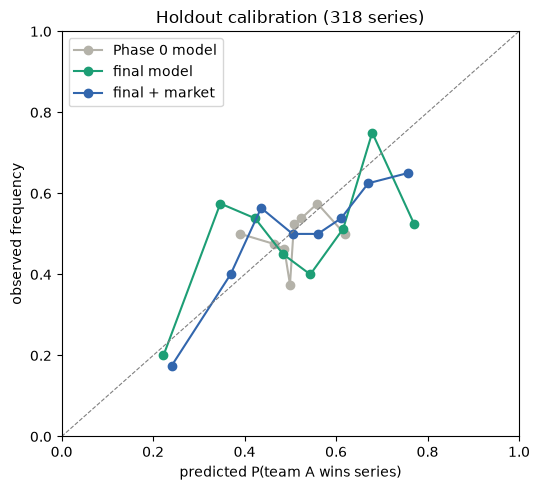

In [31]:
# calibration on the holdout: predicted vs actual, from the favourite's side
print(ev.calibration_table(hold.y, hold.p_final).round(3))

fig, ax = plt.subplots(figsize=(5.5, 5))
for col, label, colour in [("p_phase0", "Phase 0 model", "#B4B2A9"), ("p_final", "final model", "#1D9E75"),
                           ("p_blend", "final + market", "#3266AD")]:
    actual, predicted = ev.reliability(hold.y, hold[col], bins=8)
    ax.plot(predicted, actual, "o-", label=label, color=colour)
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.set(xlabel="predicted P(team A wins series)", ylabel="observed frequency",
       title=f"Holdout calibration ({len(hold)} series)", xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

Current map pool: Ascent, Haven, Split, Lotus, Summit, Sunset, Abyss
Upper quarterfinals: [('100T', 'G2'), ('VIT', 'NS'), ('NRG', 'T1'), ('PRX', 'LOUD')]


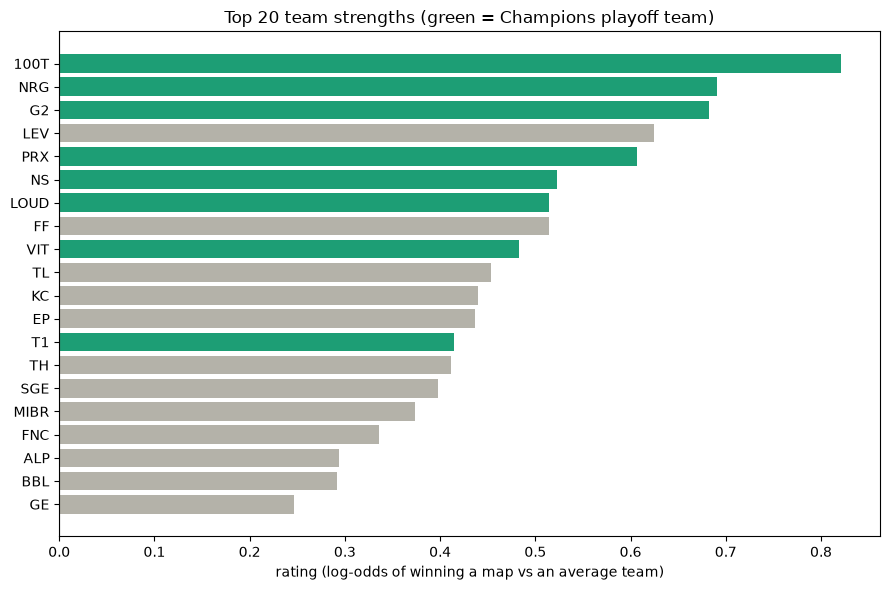

,region,rating
team,,
100T,Americas,0.821
NRG,Americas,0.691
G2,Americas,0.682
PRX,Pacific,0.606
NS,Pacific,0.522
LOUD,Americas,0.515
VIT,EMEA,0.483
T1,Pacific,0.414


In [32]:
cfg, veto, kappa = best["best"]
today = series.date.max() + pd.Timedelta(days=1)
ctx = ev.Context(series, maps, players, vetoes)

if isinstance(cfg, BTConfig):
    model = BradleyTerry(cfg).fit(maps, today, regions=ctx.regions, lineup_table=ctx.lineups)
else:
    model = Glicko2(tau=cfg[1]).fit(maps)
model = Scaled(model, best["temperature"])
pool = map_pool(vetoes, today)
habits = VetoHabits().fit(vetoes, today)
print("Current map pool:", ", ".join(pool))

qf_rows = upcoming[upcoming.event_id == config.CHAMPIONS_2026].sort_values("match_id").head(4)
QF = list(zip(qf_rows.team_a, qf_rows.team_b))
PLAYOFF_TEAMS = [t for pair in QF for t in pair]
print("Upper quarterfinals:", QF)

ratings = model.base.table().set_index("team")
ratings["rating"] *= best["temperature"]
top = ratings.head(20).assign(playoffs=lambda t: t.index.isin(PLAYOFF_TEAMS))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index[::-1], top.rating[::-1],
        color=["#1D9E75" if p else "#B4B2A9" for p in top.playoffs[::-1]])
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Top 20 team strengths (green = Champions playoff team)")
ax.set_xlabel("rating (log-odds of winning a map vs an average team)")
plt.tight_layout()
plt.show()
ratings.loc[PLAYOFF_TEAMS].sort_values("rating", ascending=False).round(3)

In [33]:
# per-map strength of the playoff teams (only if the chosen model has per-map ratings)
if isinstance(cfg, BTConfig) and cfg.per_map:
    grid = pd.DataFrame({m: [model.base.strength(t, m) * best["temperature"] for t in PLAYOFF_TEAMS]
                         for m in pool}, index=PLAYOFF_TEAMS)
    display(grid.round(2).style.background_gradient(cmap="RdYlGn", axis=None))
else:
    print("The chosen model has a single rating per team.")

,Ascent,Haven,Split,Lotus,Summit,Sunset,Abyss
100T,0.950000,0.860000,0.750000,0.820000,0.850000,0.840000,0.860000
G2,0.590000,0.610000,0.650000,0.760000,0.670000,0.770000,0.740000
VIT,0.520000,0.360000,0.460000,0.490000,0.600000,0.450000,0.500000
NS,0.420000,0.510000,0.550000,0.450000,0.560000,0.520000,0.570000
NRG,0.580000,0.820000,0.630000,0.900000,0.840000,0.480000,0.610000
T1,0.340000,0.440000,0.370000,0.530000,0.380000,0.450000,0.360000
PRX,0.720000,0.610000,0.610000,0.650000,0.680000,0.550000,0.550000
LOUD,0.400000,0.360000,0.510000,0.570000,0.610000,0.680000,0.620000


In [34]:
W = best["blend_w"]
sm_model = SeriesModel(model, pool, habits, kappa if veto else 1.0)
qf = qf_rows[["team_a", "team_b", "p_market", "n_books"]].reset_index(drop=True)
qf["p_model"] = [sm_model.prob(a, b, 3) for a, b in QF]
qf["p_blend"] = W * qf.p_model + (1 - W) * qf.p_market.fillna(qf.p_model)
qf["model_minus_market"] = qf.p_model - qf.p_market
qf.round(3)

,team_a,team_b,p_market,n_books,p_model,p_blend,model_minus_market
0,100T,G2,0.619,5.0,0.563,0.611,-0.057
1,VIT,NS,0.533,4.0,0.485,0.525,-0.048
2,NRG,T1,0.608,5.0,0.608,0.608,-0.000
3,PRX,LOUD,0.553,5.0,0.524,0.548,-0.029


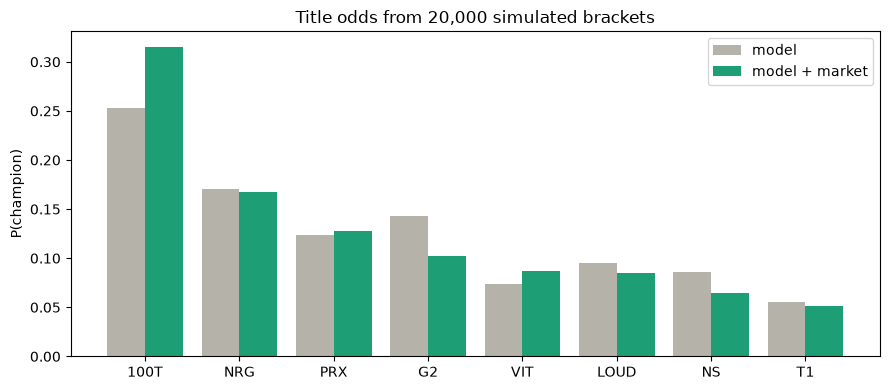

model                         model + market                        
     P(champion) P(grand final) P(top 3)    P(champion) P(grand final) P(top 3)
100T        25.3           41.1     53.1           31.5           48.0     59.4
NRG         17.0           33.4     47.4           16.8           33.7     48.0
G2          14.3           27.4     39.3           10.2           21.6     33.0
PRX         12.4           26.1     39.2           12.7           27.1     40.8
LOUD         9.5           21.4     34.5            8.5           20.1     33.2
NS           8.6           19.2     32.0            6.4           15.9     28.0
VIT          7.4           17.1     28.9            8.7           19.7     32.4
T1           5.5           14.4     25.6            5.1           13.9     25.2

In [35]:
offsets = market_offsets(model, list(zip(qf.team_a, qf.team_b, qf.p_blend)))
sm_blend = SeriesModel(Offset(model, offsets), pool, habits, kappa if veto else 1.0)

odds_model = title_odds(QF, sm_model.prob)
odds_blend = title_odds(QF, sm_blend.prob)
both = pd.concat({"model": odds_model, "model + market": odds_blend}, axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(odds_blend))
ax.bar(x - 0.2, odds_model.loc[odds_blend.index, "P(champion)"], 0.4, label="model", color="#B4B2A9")
ax.bar(x + 0.2, odds_blend["P(champion)"], 0.4, label="model + market", color="#1D9E75")
ax.set_xticks(x, odds_blend.index)
ax.set_ylabel("P(champion)")
ax.set_title("Title odds from 20,000 simulated brackets")
ax.legend()
plt.tight_layout()
plt.show()
(both * 100).round(1)

## 5. Pick sheet

In [36]:
sheet, picks = pick_sheet(QF, sm_blend.prob)
original = ["100T", "VIT", "NRG", "LOUD", "100T", "LOUD", "100T", "G2", "PRX", "NRG", "VIT", "VIT", "VIT", "100T"]
sheet["original notebook"] = original
sheet["changed"] = np.where(sheet.pick != sheet["original notebook"], "<--", "")
print(f"Champion: {picks['_champion']}   Runner-up: {picks['_runner_up']}   Third: {picks['_third']}")
print("Original notebook: champion 100T, runner-up VIT, third LOUD")
sheet.style.format({"confidence": "{:.0%}"})

Champion: 100T   Runner-up: NRG   Third: PRX
Original notebook: champion 100T, runner-up VIT, third LOUD


,match,pick,vs,confidence,original notebook,changed
1,UB QF A,100T,G2,62%,100T,
2,UB QF B,VIT,NS,52%,VIT,
3,UB QF C,NRG,T1,61%,NRG,
4,UB QF D,PRX,LOUD,54%,LOUD,<--
5,UB SF 1,100T,VIT,64%,100T,
6,UB SF 2,NRG,PRX,53%,LOUD,<--
7,UB Final,100T,NRG,58%,100T,
8,LB R1 top,G2,NS,56%,G2,
9,LB R1 bottom,LOUD,T1,54%,PRX,<--
10,LB R2 top,PRX,G2,52%,NRG,<--
